# Supply Chain & Logistics Analytics

## Business Problem Statement
The company wants to improve its supply chain performance by analyzing sales, inventory, suppliers, logistics, manufacturing, and product quality. However, the data is spread across different areas, making it difficult to identify high costs, inventory issues, supplier performance, and profitable products.

The goal of this project is to analyze the supply chain data and build an interactive dashboard that helps management make better business decisions and improve operational efficiency.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(r"C:\Users\prati\Desktop\Projects\Supply Chain & Logistics Analytics\Data\supply_chain_data.csv")
df.head()

,Product Category,SKU,Unit Price,Product Availability (%),Units Sold,Sales Revenue,Customer Gender,Current Inventory,Order Lead Time (Days),Order Quantity,Shipping Time (Days),Shipping Carrier,Shipping Cost,Supplier,Supplier Location,Supplier Lead Time (Days),Units Manufactured,Manufacturing Lead Time (Days),Manufacturing Cost,Quality Inspection Status,Defect Rate (%),Transportation Mode,Delivery Route,Transportation Cost
0,haircare,SKU0,69.808006,55,802,8661.996792,Female,58,7,96,4,DTDC,2.956572,Elite Distributors,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,2,Blue Dart,9.716575,Elite Distributors,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Male,1,10,88,2,DTDC,8.054479,Global Supply Ltd,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Female,23,13,59,6,Delhivery,1.729569,Nova Industries,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Female,5,3,56,8,Blue Dart,3.890548,Global Supply Ltd,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


## Exploratory Data Analysis (EDA)

EDA is performed to understand the data, identify patterns, and discover useful business insights.

In [3]:
df.shape

(100, 24)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Product Category                100 non-null    object 
 1   SKU                             100 non-null    object 
 2   Unit Price                      100 non-null    float64
 3   Product Availability (%)        100 non-null    int64  
 4   Units Sold                      100 non-null    int64  
 5   Sales Revenue                   100 non-null    float64
 6   Customer Gender                 100 non-null    object 
 7   Current Inventory               100 non-null    int64  
 8   Order Lead Time (Days)          100 non-null    int64  
 9   Order Quantity                  100 non-null    int64  
 10  Shipping Time (Days)            100 non-null    int64  
 11  Shipping Carrier                100 non-null    object 
 12  Shipping Cost                   100 n

In [5]:
float_col = df.select_dtypes(include='float').columns

df[float_col] = df[float_col].round(2)

In [6]:
df.describe()

,Unit Price,Product Availability (%),Units Sold,Sales Revenue,Current Inventory,Order Lead Time (Days),Order Quantity,Shipping Time (Days),Shipping Cost,Supplier Lead Time (Days),Units Manufactured,Manufacturing Lead Time (Days),Manufacturing Cost,Defect Rate (%),Transportation Cost
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462500,48.400000,460.990000,5776.048600,47.770000,15.960000,49.220000,5.750000,5.548200,17.080000,567.840000,14.77000,47.266400,2.277100,529.245700
std,31.168147,30.743317,303.780074,2732.841169,31.369372,8.785801,26.784429,2.724283,2.651879,8.846251,263.046861,8.91243,28.982778,1.461254,258.302082
min,1.700000,1.000000,8.000000,1061.620000,0.000000,1.000000,1.000000,1.000000,1.010000,1.000000,104.000000,1.00000,1.090000,0.020000,103.920000
25%,19.595000,22.750000,184.250000,2812.847500,16.750000,8.000000,26.000000,3.750000,3.542500,10.000000,352.000000,7.00000,22.985000,1.007500,318.780000
50%,51.240000,43.500000,392.500000,6006.350000,47.500000,17.000000,52.000000,6.000000,5.320000,18.000000,568.500000,14.00000,45.905000,2.140000,520.430000
75%,77.195000,75.000000,704.250000,8253.972500,73.000000,24.000000,71.250000,8.000000,7.602500,25.000000,797.000000,23.00000,68.617500,3.562500,763.080000
max,99.170000,100.000000,996.000000,9866.470000,100.000000,30.000000,96.000000,10.000000,9.930000,30.000000,985.000000,30.00000,99.470000,4.940000,997.410000


In [7]:
df.describe(include='object')

,Product Category,SKU,Customer Gender,Shipping Carrier,Supplier,Supplier Location,Quality Inspection Status,Transportation Mode,Delivery Route
count,100,100,100,100,100,100,100,100,100
unique,3,100,2,3,5,5,3,4,3
top,skincare,SKU0,Female,DTDC,Global Supply Ltd,Kolkata,Pending,Road,Route A
freq,40,1,60,43,27,25,41,29,43


In [8]:
df.isnull().sum()

Product Category                  0
SKU                               0
Unit Price                        0
Product Availability (%)          0
Units Sold                        0
Sales Revenue                     0
Customer Gender                   0
Current Inventory                 0
Order Lead Time (Days)            0
Order Quantity                    0
Shipping Time (Days)              0
Shipping Carrier                  0
Shipping Cost                     0
Supplier                          0
Supplier Location                 0
Supplier Lead Time (Days)         0
Units Manufactured                0
Manufacturing Lead Time (Days)    0
Manufacturing Cost                0
Quality Inspection Status         0
Defect Rate (%)                   0
Transportation Mode               0
Delivery Route                    0
Transportation Cost               0
dtype: int64

In [9]:
df[df.duplicated()]

,Product Category,SKU,Unit Price,Product Availability (%),Units Sold,Sales Revenue,Customer Gender,Current Inventory,Order Lead Time (Days),Order Quantity,Shipping Time (Days),Shipping Carrier,Shipping Cost,Supplier,Supplier Location,Supplier Lead Time (Days),Units Manufactured,Manufacturing Lead Time (Days),Manufacturing Cost,Quality Inspection Status,Defect Rate (%),Transportation Mode,Delivery Route,Transportation Cost


In [10]:
df['SKU'].value_counts() 

SKU
SKU0     1
SKU1     1
SKU2     1
SKU3     1
SKU4     1
        ..
SKU95    1
SKU96    1
SKU97    1
SKU98    1
SKU99    1
Name: count, Length: 100, dtype: int64

In [11]:
for col in df.columns:
    if df[col].nunique() < 20:
        print(df[col].value_counts())
        print('-'*50)

Product Category
skincare     40
haircare     34
cosmetics    26
Name: count, dtype: int64
--------------------------------------------------
Customer Gender
Female    60
Male      40
Name: count, dtype: int64
--------------------------------------------------
Shipping Time (Days)
8     16
7     14
9     11
4     10
1     10
6     10
3     10
5      8
10     6
2      5
Name: count, dtype: int64
--------------------------------------------------
Shipping Carrier
DTDC         43
Delhivery    29
Blue Dart    28
Name: count, dtype: int64
--------------------------------------------------
Supplier
Global Supply Ltd      27
Prime Manufacturing    22
Nova Industries        18
Apex Logistics         18
Elite Distributors     15
Name: count, dtype: int64
--------------------------------------------------
Supplier Location
Kolkata      25
Mumbai       22
Chennai      20
Bangalore    18
Delhi        15
Name: count, dtype: int64
--------------------------------------------------
Quality Inspection

In [12]:
df.head()

,Product Category,SKU,Unit Price,Product Availability (%),Units Sold,Sales Revenue,Customer Gender,Current Inventory,Order Lead Time (Days),Order Quantity,Shipping Time (Days),Shipping Carrier,Shipping Cost,Supplier,Supplier Location,Supplier Lead Time (Days),Units Manufactured,Manufacturing Lead Time (Days),Manufacturing Cost,Quality Inspection Status,Defect Rate (%),Transportation Mode,Delivery Route,Transportation Cost
0,haircare,SKU0,69.81,55,802,8662.00,Female,58,7,96,4,DTDC,2.96,Elite Distributors,Mumbai,29,215,29,46.28,Pending,0.23,Road,Route B,187.75
1,skincare,SKU1,14.84,95,736,7460.90,Female,53,30,37,2,Blue Dart,9.72,Elite Distributors,Mumbai,23,517,30,33.62,Pending,4.85,Road,Route B,503.07
2,haircare,SKU2,11.32,34,8,9577.75,Male,1,10,88,2,DTDC,8.05,Global Supply Ltd,Mumbai,12,971,27,30.69,Pending,4.58,Air,Route C,141.92
3,skincare,SKU3,61.16,68,83,7766.84,Female,23,13,59,6,Delhivery,1.73,Nova Industries,Kolkata,24,937,18,35.62,Fail,4.75,Rail,Route A,254.78
4,skincare,SKU4,4.81,26,871,2686.51,Female,5,3,56,8,Blue Dart,3.89,Global Supply Ltd,Delhi,5,414,3,92.07,Fail,3.15,Air,Route A,923.44


In [13]:
df.rename(columns= {
    'Order Lead Time (Days)': 'Order Lead Time',
    'Shipping Time (Days)': 'Shipping Time',
    'Supplier Lead Time (Days)': 'Supplier Lead Time',
    'Manufacturing Lead Time (Days)': 'Manufacturing Lead Time',
    'Current Inventory': 'Inventory Level'
}, inplace=True)

In [14]:
df.head()

,Product Category,SKU,Unit Price,Product Availability (%),Units Sold,Sales Revenue,Customer Gender,Inventory Level,Order Lead Time,Order Quantity,Shipping Time,Shipping Carrier,Shipping Cost,Supplier,Supplier Location,Supplier Lead Time,Units Manufactured,Manufacturing Lead Time,Manufacturing Cost,Quality Inspection Status,Defect Rate (%),Transportation Mode,Delivery Route,Transportation Cost
0,haircare,SKU0,69.81,55,802,8662.00,Female,58,7,96,4,DTDC,2.96,Elite Distributors,Mumbai,29,215,29,46.28,Pending,0.23,Road,Route B,187.75
1,skincare,SKU1,14.84,95,736,7460.90,Female,53,30,37,2,Blue Dart,9.72,Elite Distributors,Mumbai,23,517,30,33.62,Pending,4.85,Road,Route B,503.07
2,haircare,SKU2,11.32,34,8,9577.75,Male,1,10,88,2,DTDC,8.05,Global Supply Ltd,Mumbai,12,971,27,30.69,Pending,4.58,Air,Route C,141.92
3,skincare,SKU3,61.16,68,83,7766.84,Female,23,13,59,6,Delhivery,1.73,Nova Industries,Kolkata,24,937,18,35.62,Fail,4.75,Rail,Route A,254.78
4,skincare,SKU4,4.81,26,871,2686.51,Female,5,3,56,8,Blue Dart,3.89,Global Supply Ltd,Delhi,5,414,3,92.07,Fail,3.15,Air,Route A,923.44


## Feature Engineering

New business columns were created to make the analysis more meaningful.

- Total Cost
- Profit
- Profit Margin
- Inventory Status

In [15]:
df['Total Cost'] = df['Manufacturing Cost'] + df['Shipping Cost'] + df['Transportation Cost']

In [16]:
df['Profit'] = df['Sales Revenue'] - df['Total Cost']

In [17]:
df['Profit Margin (%)'] = df['Profit'] / df['Sales Revenue'] * 100

In [18]:
def inventory_status(level):
    if level <= 30:
        return "Low"
    elif level <= 70:
        return "Medium"
    else:
        return "High"

df['Inventory Status'] = df['Inventory Level'].apply(inventory_status)

In [19]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

categorical_cols = df.select_dtypes(include='object').columns

In [20]:
df[numerical_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Unit Price,100.0,49.46,31.17,1.70,19.60,51.24,77.19,99.17
Product Availability (%),100.0,48.40,30.74,1.00,22.75,43.50,75.00,100.00
Units Sold,100.0,460.99,303.78,8.00,184.25,392.50,704.25,996.00
Sales Revenue,100.0,5776.05,2732.84,1061.62,2812.85,6006.35,8253.97,9866.47
Inventory Level,100.0,47.77,31.37,0.00,16.75,47.50,73.00,100.00
Order Lead Time,100.0,15.96,8.79,1.00,8.00,17.00,24.00,30.00
Order Quantity,100.0,49.22,26.78,1.00,26.00,52.00,71.25,96.00
Shipping Time,100.0,5.75,2.72,1.00,3.75,6.00,8.00,10.00
Shipping Cost,100.0,5.55,2.65,1.01,3.54,5.32,7.60,9.93
Supplier Lead Time,100.0,17.08,8.85,1.00,10.00,18.00,25.00,30.00


In [37]:
pd.pivot_table(df, values='Sales Revenue', index='Supplier', columns='Product Category', aggfunc='sum')

Product Category,cosmetics,haircare,skincare
Supplier,,,
Apex Logistics,25859.56,41918.24,18691.17
Elite Distributors,7698.42,28625.75,61471.81
Global Supply Ltd,33226.37,27576.17,96726.44
Nova Industries,50160.42,18944.65,41238.41
Prime Manufacturing,44576.50,57390.61,23500.34


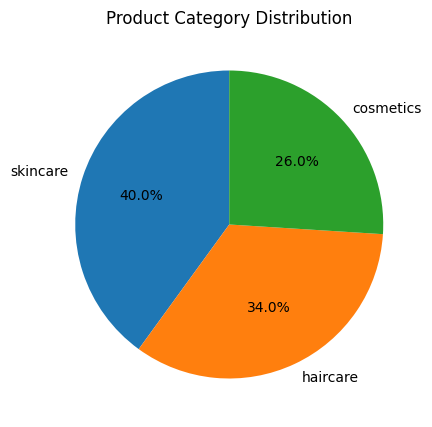

In [21]:
# Product Category

category_counts = df['Product Category'].value_counts()

plt.figure(figsize=(5,5))

plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90)

plt.title('Product Category Distribution')

plt.show()

In [22]:
# Revenue by product category

revenue_by_category = df.groupby('Product Category')['Sales Revenue'].sum().sort_values(ascending=False).reset_index()
revenue_by_category

,Product Category,Sales Revenue
0,skincare,241628.17
1,haircare,174455.42
2,cosmetics,161521.27


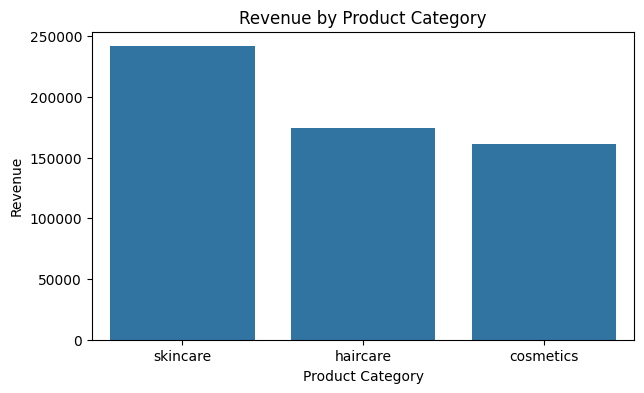

In [23]:
plt.figure(figsize=(7,4))

sns.barplot(data=revenue_by_category, x='Product Category', y='Sales Revenue')

plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')

plt.show()

### Insight

- Some product categories generate more revenue than others.
- High-performing categories contribute more to overall sales.

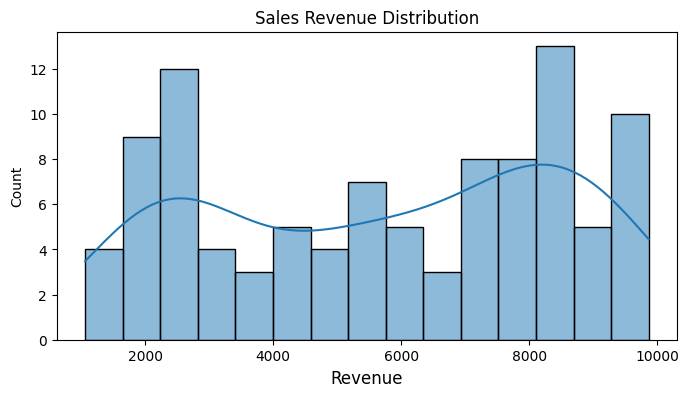

In [24]:
# Revenue

plt.figure(figsize=(8,4))
sns.histplot(df['Sales Revenue'], bins=15, kde=True)
plt.title('Sales Revenue Distribution')
plt.xlabel('Revenue', fontsize=12)

plt.show()

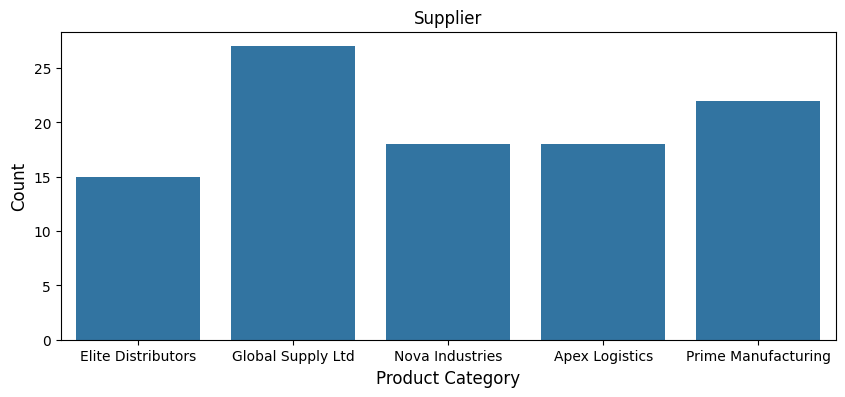

In [25]:
#Supplier

plt.figure(figsize=(10,4))
sns.countplot(data=df, x='Supplier')
plt.title('Supplier')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.show()

In [26]:
# Revenue by Supplier

revenue_by_supplier = df.groupby('Supplier')['Sales Revenue'].sum().sort_values(ascending=False).reset_index()
revenue_by_supplier

,Supplier,Sales Revenue
0,Global Supply Ltd,157528.98
1,Prime Manufacturing,125467.45
2,Nova Industries,110343.48
3,Elite Distributors,97795.98
4,Apex Logistics,86468.97


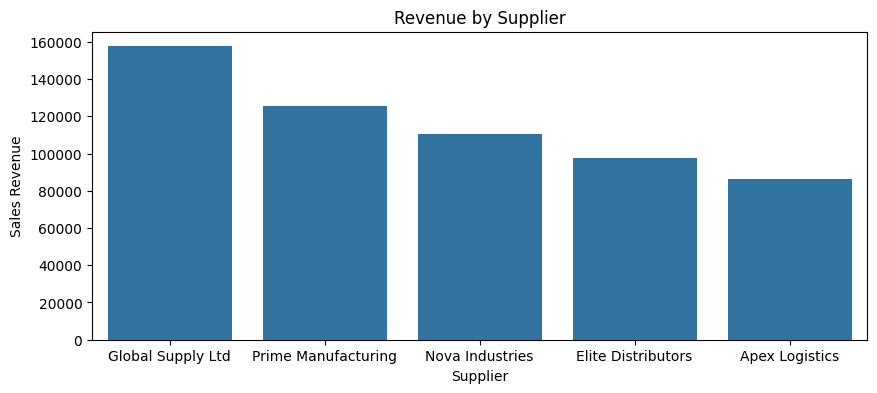

In [27]:
plt.figure(figsize=(10,4))

sns.barplot(data=revenue_by_supplier, x='Supplier', y='Sales Revenue')

plt.title('Revenue by Supplier')
plt.xlabel('Supplier')
plt.ylabel('Sales Revenue')

plt.show()

### Insight

- Revenue varies between suppliers.
- Top suppliers contribute a large share of total revenue.

In [28]:
# Profit by Product Category

profit_by_category = df.groupby('Product Category')['Profit'].sum().sort_values(ascending=False).reset_index()
profit_by_category

,Product Category,Profit
0,skincare,217242.74
1,haircare,155278.15
2,cosmetics,146877.94


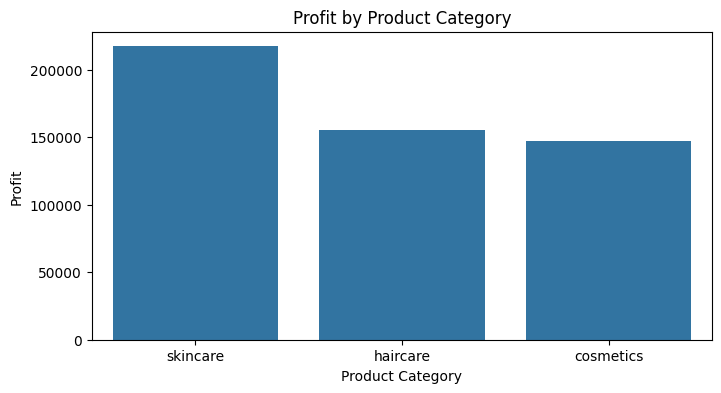

In [29]:
plt.figure(figsize=(8,4))

sns.barplot(data=profit_by_category, x='Product Category', y='Profit')

plt.title('Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Profit')

plt.show()

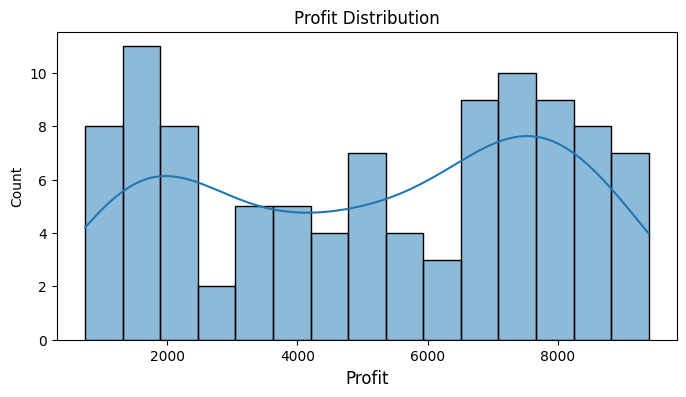

In [52]:
# profit 

plt.figure(figsize=(8,4))
sns.histplot(df['Profit'], bins=15, kde=True)
plt.title('Profit Distribution')
plt.xlabel('Profit', fontsize=12)

plt.show()

In [31]:
# Average Defect Rate by supplier

df.groupby('Supplier')['Defect Rate (%)'].mean()

Supplier
Apex Logistics         2.338889
Elite Distributors     2.466000
Global Supply Ltd      1.803333
Nova Industries        2.665000
Prime Manufacturing    2.361818
Name: Defect Rate (%), dtype: float64

In [32]:
defect_rate_by_supplier = df.groupby('Supplier')['Defect Rate (%)'].sum().sort_values(ascending=False).reset_index()
defect_rate_by_supplier

,Supplier,Defect Rate (%)
0,Prime Manufacturing,51.96
1,Global Supply Ltd,48.69
2,Nova Industries,47.97
3,Apex Logistics,42.10
4,Elite Distributors,36.99


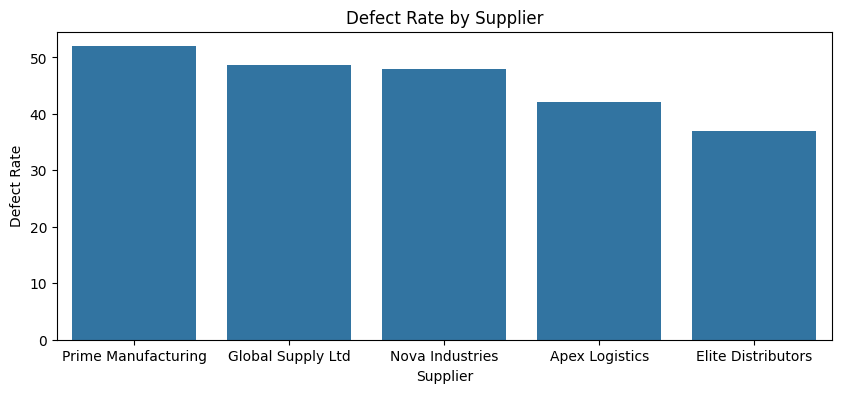

In [33]:
plt.figure(figsize=(10,4))

sns.barplot(data=defect_rate_by_supplier, x='Supplier', y='Defect Rate (%)')

plt.title('Defect Rate by Supplier')
plt.xlabel('Supplier')
plt.ylabel('Defect Rate')

plt.show()

### Insight

- Some suppliers have better product quality than others.
- High defect rates may affect customer satisfaction.

In [34]:
# Average Shipping Cost by Shipping Carrier

df.groupby('Shipping Carrier')['Shipping Cost'].mean()

Shipping Carrier
Blue Dart    5.555000
DTDC         5.509070
Delhivery    5.599655
Name: Shipping Cost, dtype: float64

In [35]:
shipping_cost_by_carrier = df.groupby('Shipping Carrier')['Shipping Cost'].sum().sort_values(ascending=False).reset_index()
shipping_cost_by_carrier

,Shipping Carrier,Shipping Cost
0,DTDC,236.89
1,Delhivery,162.39
2,Blue Dart,155.54


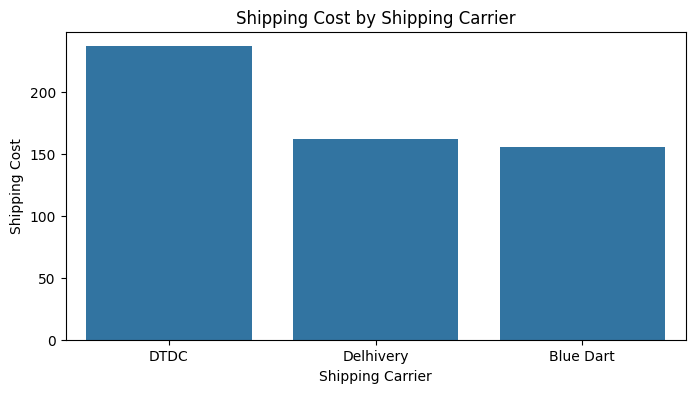

In [36]:
plt.figure(figsize=(8,4))

sns.barplot(data=shipping_cost_by_carrier, x='Shipping Carrier', y='Shipping Cost')

plt.title('Shipping Cost by Shipping Carrier')
plt.xlabel('Shipping Carrier')
plt.ylabel('Shipping Cost')

plt.show()

### Insight

- Shipping costs are different across carriers.
- Lower-cost carriers may help reduce logistics expenses.

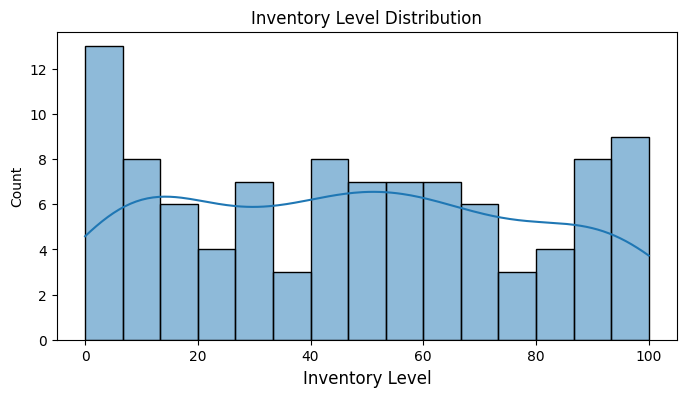

In [38]:
# Inventory Level 

plt.figure(figsize=(8,4))
sns.histplot(df['Inventory Level'], bins=15, kde=True)
plt.title('Inventory Level Distribution')
plt.xlabel('Inventory Level', fontsize=12)

plt.show()

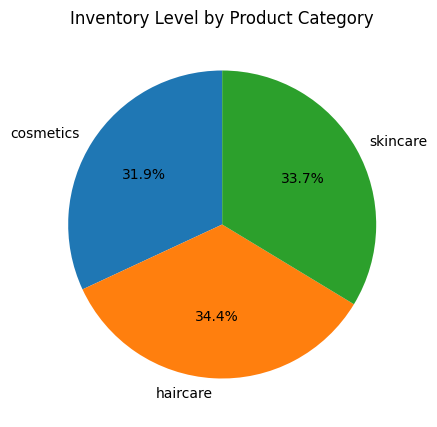

In [51]:
# Inventory Level by Product Category

inventory =  df.groupby('Product Category')['Inventory Level'].sum()

plt.figure(figsize=(5,5))

plt.pie(inventory, labels=inventory.index, autopct='%1.1f%%', startangle=90)

plt.title('Inventory Level by Product Category')

plt.show()

### Insight

- Most products have a moderate inventory level.
- Products with low inventory may need restocking.

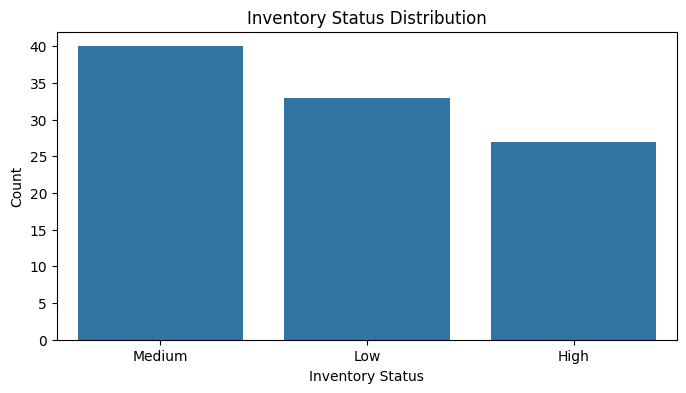

In [48]:
# Inventory Status

plt.figure(figsize=(8,4))

sns.countplot(data=df, x='Inventory Status')

plt.title('Inventory Status Distribution')
plt.xlabel('Inventory Status')
plt.ylabel('Count')

plt.show()

### Insight

- Most products have a healthy inventory level.
- Low inventory items should be monitored.

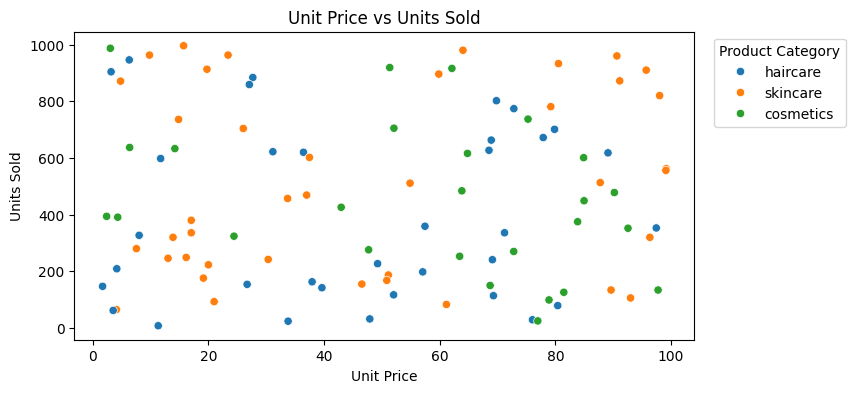

In [39]:
plt.figure(figsize=(8,4))

sns.scatterplot(data=df, x='Unit Price', y='Units Sold', hue='Product Category')

plt.title('Unit Price vs Units Sold')

plt.legend(title='Product Category', bbox_to_anchor=(1.02,1))


plt.show()

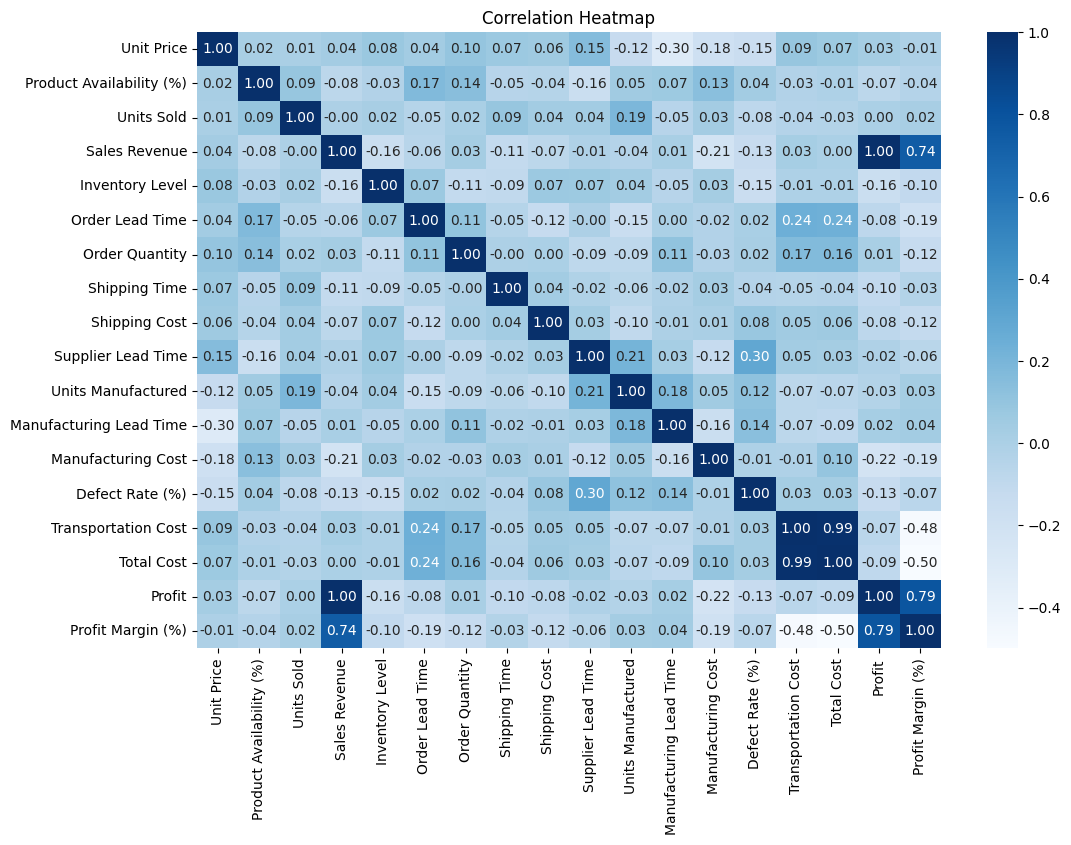

In [40]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap( corr, annot=True, cmap='Blues', fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()

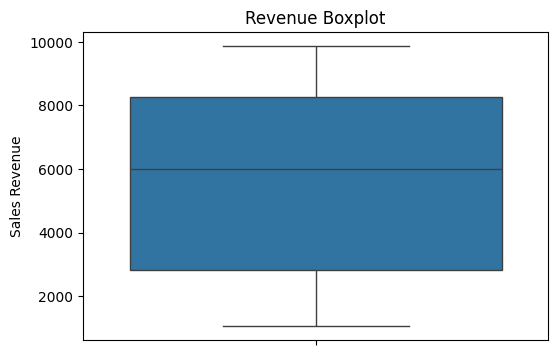

In [41]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df['Sales Revenue'])

plt.title('Revenue Boxplot')

plt.show()

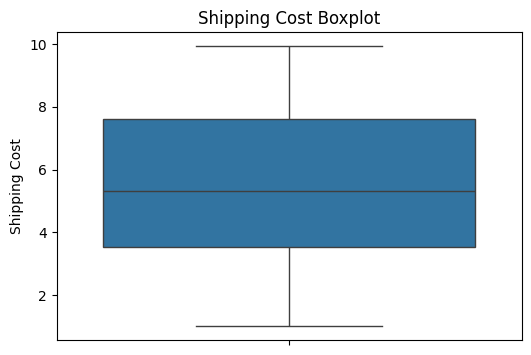

In [42]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df['Shipping Cost'])

plt.title('Shipping Cost Boxplot')

plt.show()

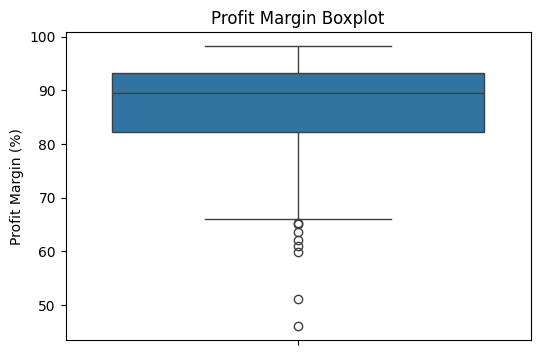

In [43]:
plt.figure(figsize=(6,4))

sns.boxplot(y=df['Profit Margin (%)'])

plt.title('Profit Margin Boxplot')

plt.show()

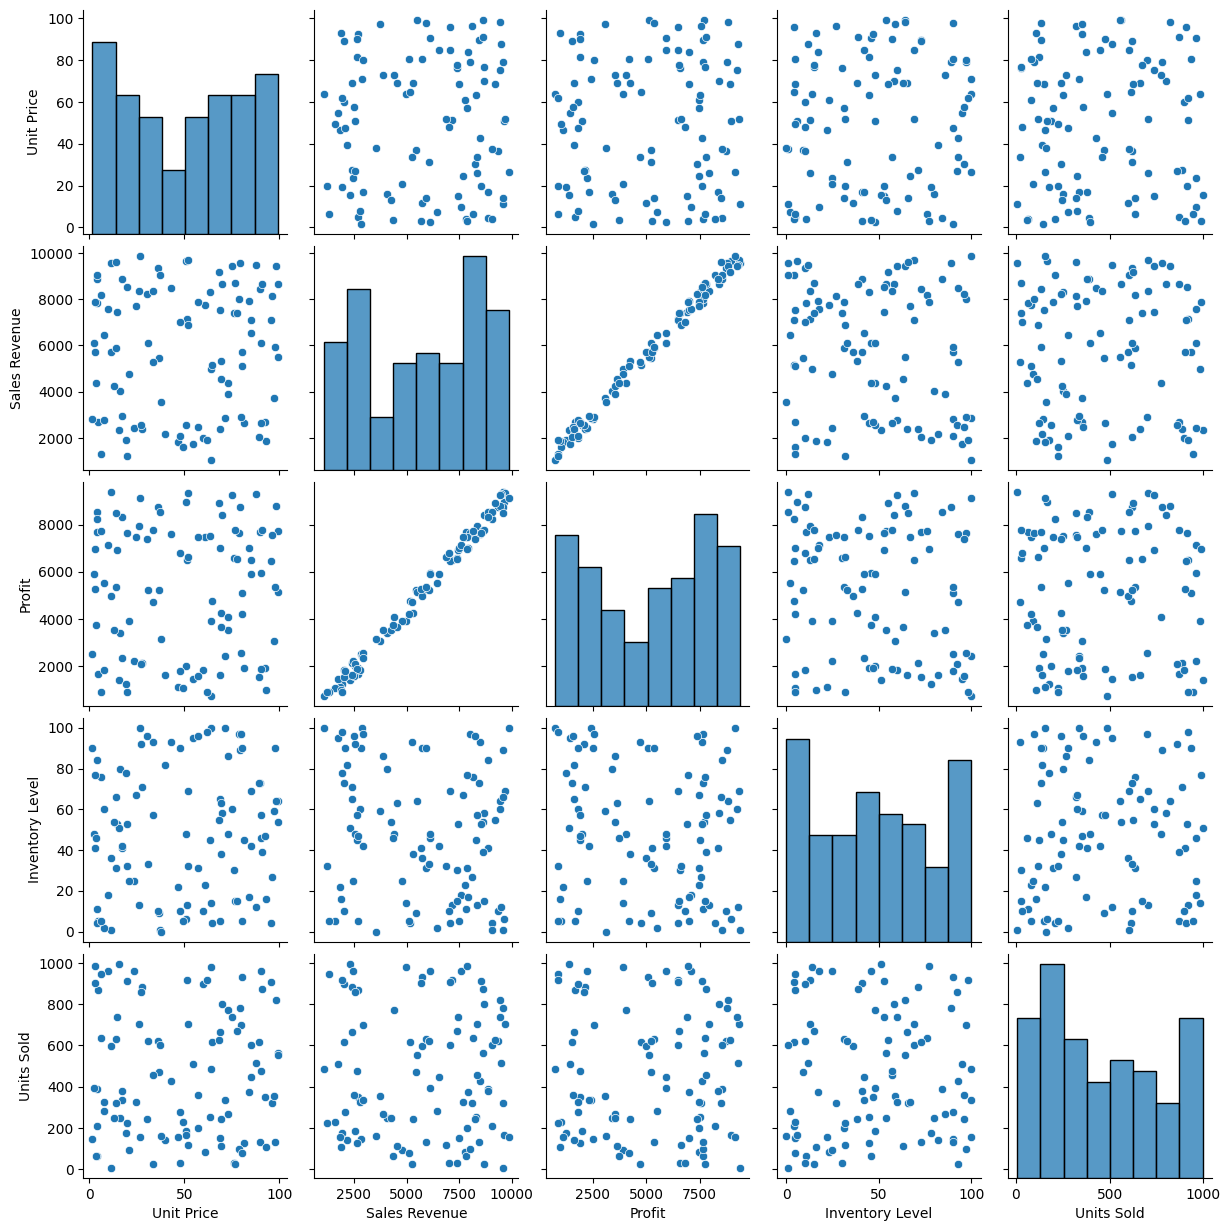

In [54]:
sns.pairplot(df[['Unit Price', 'Sales Revenue', 'Profit', 'Inventory Level', 'Units Sold']])

plt.show()

# Conclusion

The analysis provides a clear view of the company's supply chain performance.

Key findings:
- Revenue differs across product categories and suppliers.
- Inventory levels should be monitored regularly.
- Supplier quality and logistics costs affect overall performance.
- Data insights can support better business decisions.

# Recommendations

- Maintain sufficient inventory for high-demand products.
- Improve the performance of suppliers with high defect rates.
- Choose cost-effective shipping carriers.
- Monitor low-profit products and reduce unnecessary costs.
- Use dashboards to track key business metrics regularly.